In [2]:
import numpy as np 
import pandas as pd

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
jobs_df=pd.read_csv("../data/jobs.csv")

In [5]:
skills_df=pd.read_csv("../data/skills_combined.csv")

In [6]:
job_skills_df=pd.read_csv("../data/job_skills.csv")

In [7]:
print(jobs_df.shape)
print(jobs_df.columns)

(50, 8)
Index(['job_id', 'company_name', 'role', 'location', 'job_description',
       'required_skills', 'preferred_skills', 'experience_req'],
      dtype='object')


In [8]:
print(skills_df.shape)
print(skills_df.columns)

(151, 2)
Index(['skill_id', 'skill_name'], dtype='object')


In [9]:
print(job_skills_df.shape)
print(job_skills_df.columns)

(500, 3)
Index(['job_id', 'skill_id', 'skill_type'], dtype='object')


In [10]:
job_skills_df.head()

,job_id,skill_id,skill_type
0,JOB001,73,Required
1,JOB001,111,Required
2,JOB001,97,Required
3,JOB001,22,Required
4,JOB001,81,Required


In [11]:
merged_df= job_skills_df.merge(skills_df,on="skill_id",how="left")

In [12]:
merged_df.head()

,job_id,skill_id,skill_type,skill_name
0,JOB001,73,Required,Java
1,JOB001,111,Required,Python
2,JOB001,97,Required,OOP Concepts
3,JOB001,22,Required,Basic SQL
4,JOB001,81,Required,Logical Reasoning


In [13]:
top_10_skills = merged_df["skill_name"].value_counts().head(10)

In [14]:
top_10_skills

skill_name
SQL                     39
Communication Skills    32
Git                     25
Power BI                18
MS Excel                18
JIRA                    16
Python basics           15
Analytical Thinking     13
Attention to Detail     10
DAX                     10
Name: count, dtype: int64

In [37]:
required_skills=merged_df[merged_df["skill_type"]=="Required"]

In [38]:
top_required=required_skills["skill_name"].value_counts().head(10)

In [39]:
top_required

skill_name
SQL                     32
Communication Skills    31
MS Excel                18
Analytical Thinking     13
Power BI                10
Attention to Detail     10
Problem Solving          9
OOP                      8
Windows OS               7
PowerPoint               6
Name: count, dtype: int64

In [31]:
Preferred_skills=merged_df[merged_df["skill_type"]=="Preferred"]

In [32]:
top_Preferred = Preferred_skills["skill_name"].value_counts().head(10)

In [33]:
top_Preferred

skill_name
Git                25
JIRA               16
Python basics      12
DAX                10
ITIL Foundation     9
Power BI            8
Tableau             7
ServiceNow          7
SQL                 7
Statistics          7
Name: count, dtype: int64

In [34]:
company_skill_counts = jobs_df.merge(job_skills_df, on="job_id").merge(skills_df, on="skill_id")

In [35]:
company_skill_counts.groupby("company_name")["skill_name"].count().sort_values(ascending=False).head(10)

company_name
Wipro                              30
Capgemini                          30
Mphasis                            29
Cognizant Technology Solutions     29
HCL Technologies                   29
TCS (Tata Consultancy Services)    22
Zensar Technologies                21
Hexaware Technologies              21
Infosys                            20
Accenture                          19
Name: skill_name, dtype: int64

In [36]:
# JOBS POSTED BY EACH COMPANY
jobs_df["company_name"].value_counts()

company_name
Cognizant Technology Solutions     3
Wipro                              3
Mphasis                            3
Capgemini                          3
HCL Technologies                   3
Infosys                            2
TCS (Tata Consultancy Services)    2
Accenture                          2
Genpact                            2
Zensar Technologies                2
Hexaware Technologies              2
Tata Consultancy Services (TCS)    1
L&T Infotech (LTIMindtree)         1
Fractal Analytics                  1
EXL Service                        1
Mu Sigma                           1
WNS Global Services                1
Tech Mahindra                      1
PwC India                          1
Deloitte India                     1
Infosys BPM                        1
KPMG India                         1
NIIT Technologies (Coforge)        1
Persistent Systems                 1
Infosys BPO                        1
Birlasoft                          1
ICICI Bank (iProcess)    

jobs_df["role"].value_counts().head(10)

# Today's Insights


## 1. Most Demanded Skills
- SQL emerged as the most demanded skill with 39 occurrences, followed by Communication Skills (32) and Git (25).
- This indicates that employers seek a combination of database skills, collaboration tools, and communication abilities in fresher candidates.

## 2. Required Skills
- SQL (32) and Communication Skills (31) were the most frequently required skills. 
- MS Excel (18) and Power BI (10) also appeared prominently, highlighting the importance of data handling and reporting skills for entry-level roles.

## 3. Preferred Skills
- Git (25) and JIRA (16) were the most common preferred skills. 
- These tools support software development and Agile workflows, suggesting that candidates with practical project experience gain a competitive advantage.

## 4. Dataset Observation
- The dataset is heavily oriented toward analyst, support, and service-based roles.
- Future versions of the dataset should include more Software Engineer, Java Developer, Backend Developer, and Full Stack Developer roles to better reflect campus placement opportunities.

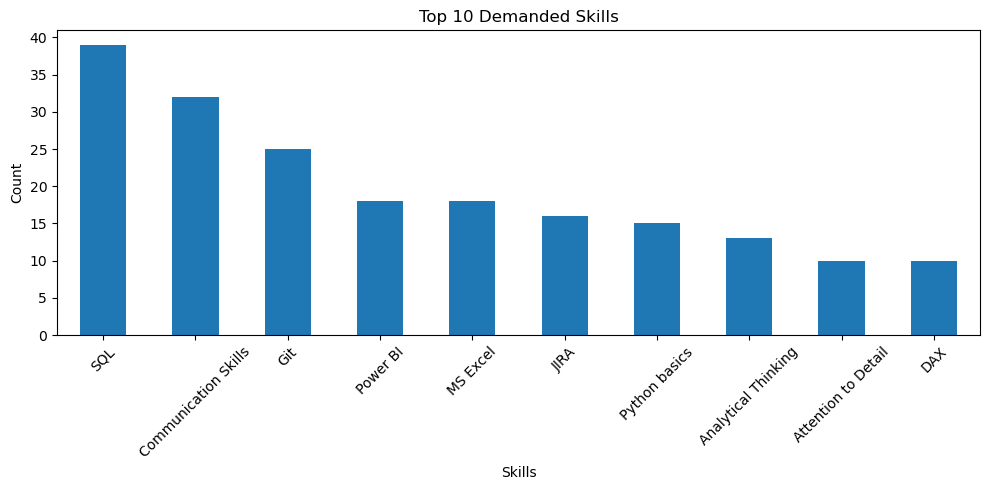

In [25]:
plt.figure(figsize=(10,5))

top_10_skills.plot(kind="bar")

plt.title("Top 10 Demanded Skills")
plt.xlabel("Skills")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Insights
- SQL emerged as the most demanded skill, followed by Communication Skills and Git.
- This indicates that employers seek both technical and collaboration skills in fresher candidates.

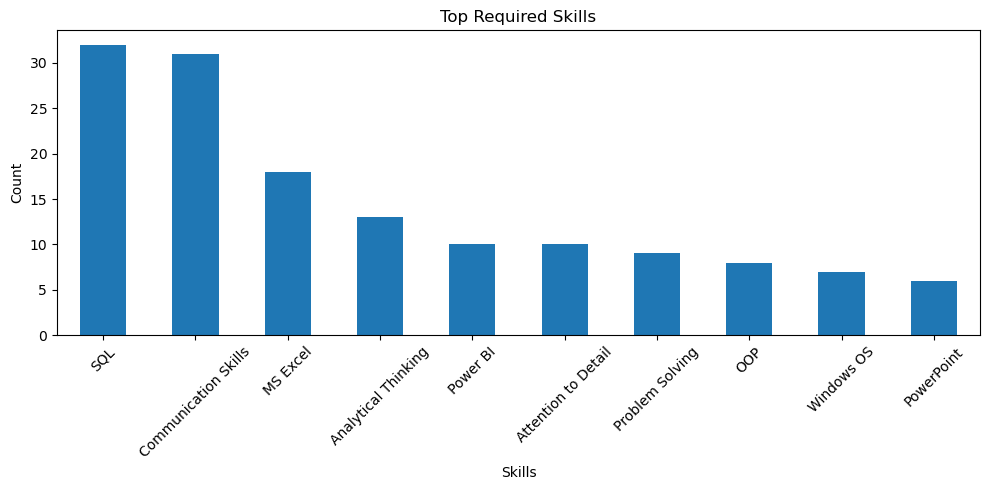

In [40]:
plt.figure(figsize=(10,5))

top_required.plot(kind="bar")

plt.title("Top Required Skills")
plt.xlabel("Skills")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Insights 
- SQL and Communication Skills were the most frequently required skills. 
- MS Excel and Power BI also appeared prominently, highlighting the importance of data handling skills.

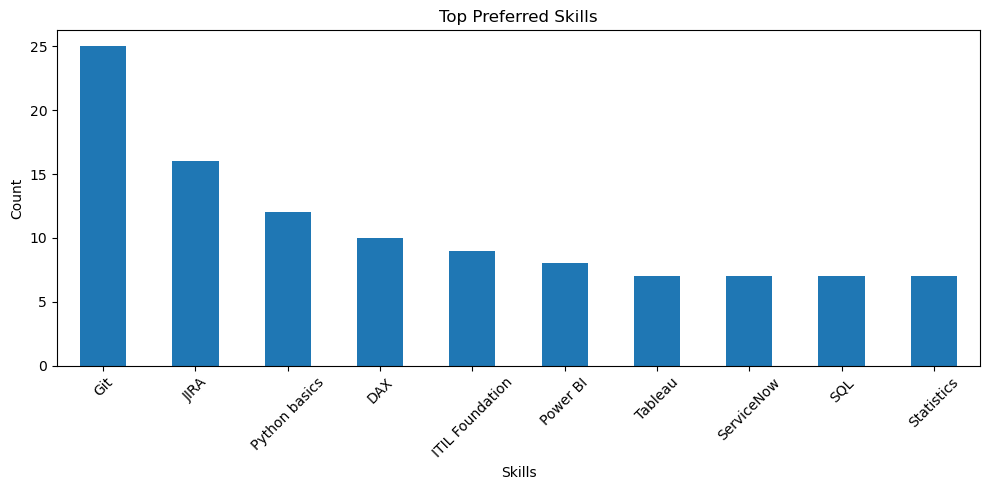

In [42]:
plt.figure(figsize=(10,5))

top_Preferred.plot(kind="bar")

plt.title("Top Preferred Skills")
plt.xlabel("Skills")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Insights
- Git and JIRA were the most common preferred skills, indicating that employers value familiarity with collaboration and Agile development tools.

In [43]:
company_jobs = jobs_df["company_name"].value_counts().head(10)

In [44]:
company_jobs

company_name
Cognizant Technology Solutions     3
Wipro                              3
Mphasis                            3
Capgemini                          3
HCL Technologies                   3
Infosys                            2
TCS (Tata Consultancy Services)    2
Accenture                          2
Genpact                            2
Zensar Technologies                2
Name: count, dtype: int64

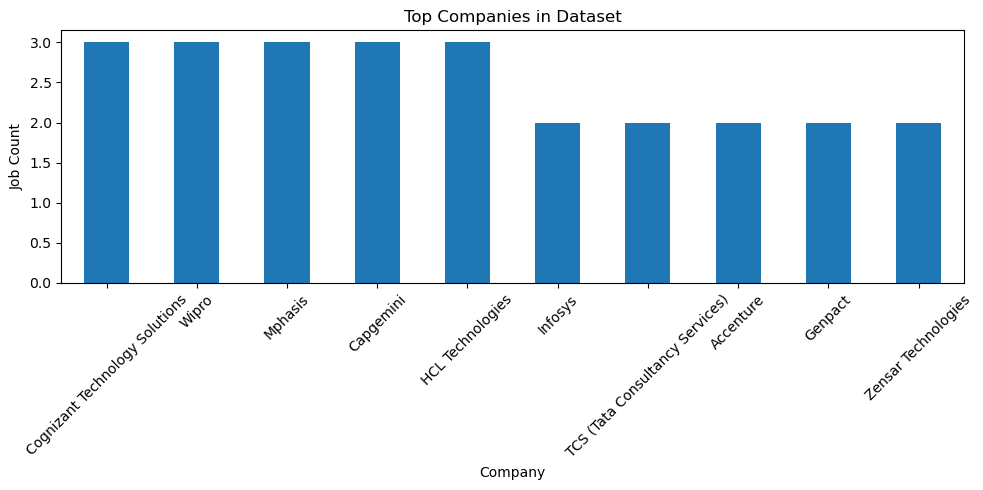

In [45]:
plt.figure(figsize=(10,5))

company_jobs.plot(kind="bar")

plt.title("Top Companies in Dataset")
plt.xlabel("Company")
plt.ylabel("Job Count")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Insights
- The dataset contains a strong representation of service-based companies such as Cognizant,Wipro,Mphasis,Capgemini etc.

In [47]:
jobs_df.head(3)

,job_id,company_name,role,location,job_description,required_skills,preferred_skills,experience_req
0,JOB001,Tata Consultancy Services (TCS),System Engineer,"Chennai, Tamil Nadu",TCS is hiring System Engineers under its NQT N...,"Java, Python, OOP Concepts, Basic SQL, Logical...","Data Structures & Algorithms, Git, Linux Basic...",0 – 1 Year (Freshers)
1,JOB002,Infosys,System Engineer,"Bengaluru, Karnataka",Infosys is hiring System Engineers through its...,"Core Java, Python, SQL, OOP, Problem Solving, ...","Spring Framework, Hibernate, REST APIs, Git",0 – 1 Year (Freshers)
2,JOB003,Wipro,Project Engineer,"Pune, Maharashtra",Wipro's NLTH (National Level Talent Hunt) trac...,"Core Java, SQL, OOP, Data Structures, Verbal C...","Selenium, Maven, Spring Boot, Linux, Git",0 – 1 Year (Freshers)


In [48]:
role_count=jobs_df["role"].value_counts().head(10)

In [49]:
role_count

role
Technical Support Engineer                   3
Junior Data Analyst                          3
System Engineer                              2
Graduate Engineer Trainee                    2
Data Analyst – Fresher                       2
Data Operations Associate                    2
Associate Software Engineer                  2
Application Support Analyst                  2
Trainee Decision Scientist – Data Analyst    1
Graduate Trainee Engineer                    1
Name: count, dtype: int64

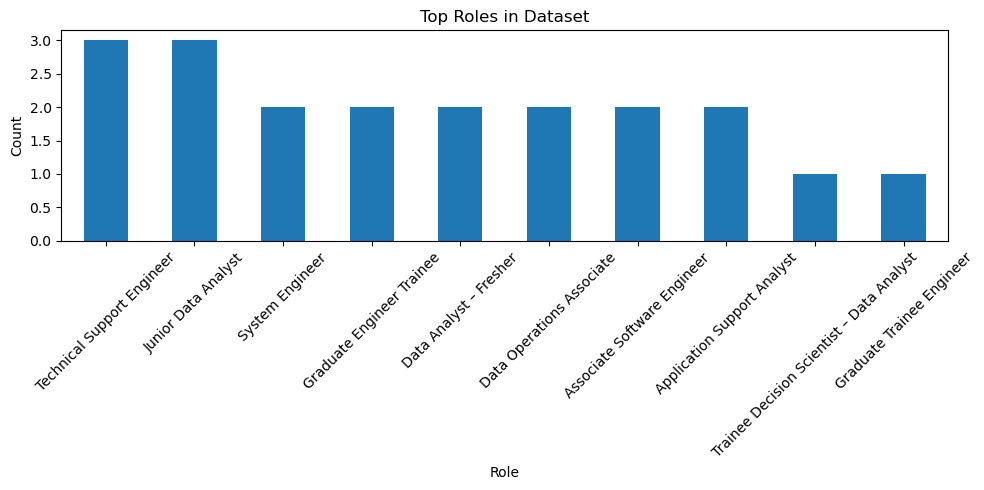

In [51]:
plt.figure(figsize=(10,5))

role_count.plot(kind="bar")

plt.title("Top Roles in Dataset")
plt.xlabel("Role")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Insights
- The dataset contains a diverse set of fresher roles, with Technical Support Engineer and Junior Data Analyst appearing most frequently.
- The role distribution suggests a stronger focus on service-based and analyst-oriented positions rather than pure software development roles.

In [55]:
top_10_skills.to_csv("../data/top_skills.csv")

top_required.to_csv("../data/top_required_skills.csv")

top_Preferred.to_csv("../data/top_preferred_skills.csv")

company_jobs.to_csv("../data/top_companies.csv")

role_count.to_csv("../data/top_roles.csv")

# Today's Insights 

1. SQL emerged as the most demanded skill.
2. Communication Skills were highly valued across roles.
3. Git and JIRA appeared as common preferred skills.
4. Service-based companies dominated the dataset.
5. The dataset contains more analyst and support roles than software engineering roles.
6. Future versions should include additional Software Engineer, Java Developer, and Backend Developer roles.